# 3. Modeles Individuels — 3 Modeles Specialises

Entrainement de 3 modeles separes (age, genre, ethnicite) avec le meilleur backbone.

**Strategie 1 du sujet** : trois modeles specialises.

**Priorite** : plus d'epochs pour genre et ethnicite.


In [ ]:
import os, sys, gc, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reproductibilite
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_ETHNICITY = 5

PROJECT_ROOT = os.path.dirname(os.getcwd())
if os.path.basename(os.getcwd()) != "training":
    PROJECT_ROOT = os.getcwd()

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "UTKFace")
OUTPUT_DIR = os.path.join(
    (
        os.getcwd()
        if os.path.basename(os.getcwd()) == "training"
        else os.path.join(os.getcwd(), "training")
    ),
    "output_v2",
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

ETHNICITY_LABELS = ["White", "Black", "Asian", "Indian", "Other"]
GENDER_LABELS = ["Male", "Female"]

# GPU setup
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

try:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision float16 activee")
except Exception as exc:
    print(f"Mixed precision non activee: {exc}")

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

2026-03-27 17:12:12.304928: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 17:12:12.666557: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-27 17:12:13.764396: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Mixed precision float16 activee
TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
DATA_DIR: /home/optimalako/Projet/SAE/data/UTKFace
OUTPUT_DIR: /home/optimalako/Projet/SAE/training/output_v2


## 3.1 Chargement des donnees


In [ ]:
def load_dataset_info(data_dir):
    file_paths, all_ages, all_genders, all_ethnicities = [], [], [], []
    skipped = 0
    for fname in sorted(os.listdir(data_dir)):
        if not fname.lower().endswith(".jpg"):
            continue
        parts = fname.split("_")
        if len(parts) < 4:
            skipped += 1
            continue
        try:
            age, gender, ethnicity = int(parts[0]), int(parts[1]), int(parts[2])
        except ValueError:
            skipped += 1
            continue
        if age < 0 or age > 116 or gender not in (0, 1) or ethnicity not in range(5):
            skipped += 1
            continue
        file_paths.append(os.path.join(data_dir, fname))
        all_ages.append(age)
        all_genders.append(gender)
        all_ethnicities.append(ethnicity)
    print(f"Images: {len(file_paths)}, ignorees: {skipped}")
    return (
        np.array(file_paths),
        np.array(all_ages, dtype=np.float32),
        np.array(all_genders, dtype=np.float32),
        np.array(all_ethnicities, dtype=np.int32),
    )


paths, ages, genders, ethnicities = load_dataset_info(DATA_DIR)

# Poids de classe pour ethnicite (desequilibree)
eth_counts = np.bincount(ethnicities, minlength=NUM_ETHNICITY)
eth_weights = len(ethnicities) / (NUM_ETHNICITY * eth_counts.astype(np.float32))
eth_weights = eth_weights / eth_weights.sum() * NUM_ETHNICITY
print(f"Poids ethnicite: {dict(zip(ETHNICITY_LABELS, eth_weights.round(2)))}")

# Split stratifie
idx = np.arange(len(paths))
idx_train, idx_test = train_test_split(
    idx, test_size=0.15, random_state=SEED, stratify=ethnicities
)
idx_train, idx_val = train_test_split(
    idx_train, test_size=0.176, random_state=SEED, stratify=ethnicities[idx_train]
)
print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")

Images: 23705, ignorees: 3
Poids ethnicite: {'White': np.float32(0.34), 'Black': np.float32(0.76), 'Asian': np.float32(1.0), 'Indian': np.float32(0.87), 'Other': np.float32(2.03)}
Train: 16602, Val: 3547, Test: 3556


In [ ]:
def load_and_preprocess(path, age, gender, ethnicity):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, {
        "age_output": age,
        "gender_output": gender,
        "ethnicity_output": ethnicity,
    }


def augment_image(img, labels):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE + 16, IMG_SIZE + 16)
    img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, 3])
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, labels


def make_dataset(indices, augment=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths[indices], ages[indices], genders[indices], ethnicities[indices])
    )
    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(indices), 2048), reshuffle_each_iteration=True
        )
    ds = ds.map(load_and_preprocess, num_parallel_calls=4)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=4)
    return ds.batch(BATCH_SIZE).prefetch(2)


train_ds = make_dataset(idx_train, augment=True)
val_ds = make_dataset(idx_val, augment=False, shuffle=False)
test_ds = make_dataset(idx_test, augment=False, shuffle=False)
print("Datasets prets.")

I0000 00:00:1774627935.740934  155972 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3445 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets prets.


## 3.2 Focal Loss


In [ ]:
class SparseFocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        indices = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1)
        p_t = tf.gather_nd(y_pred, indices)
        ce = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        if self.class_weights is not None:
            alpha_t = tf.gather(self.class_weights, y_true)
            return alpha_t * focal_weight * ce
        return focal_weight * ce

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "gamma": self.gamma,
                "class_weights": (
                    self.class_weights.numpy().tolist()
                    if self.class_weights is not None
                    else None
                ),
            }
        )
        return config


focal_loss = SparseFocalLoss(
    gamma=2.0,
    class_weights=tf.constant(eth_weights, dtype=tf.float32),
    name="focal_loss",
)
print("Focal Loss prete.")

Focal Loss prete.


## 3.3 Charger le meilleur backbone


In [ ]:
import json

config_path = os.path.join(OUTPUT_DIR, "best_backbone.json")
if os.path.exists(config_path):
    with open(config_path) as f:
        config = json.load(f)
    best_backbone = config["best_backbone"]
    print(f"Meilleur backbone (depuis comparaison): {best_backbone}")
else:
    best_backbone = "EfficientNetB0"
    print(f"Pas de config trouvee, utilisation par defaut: {best_backbone}")

Meilleur backbone (depuis comparaison): EfficientNetB0


## 3.4 Construction d'un modele individuel


In [ ]:
def build_individual(task, backbone_name):
    """Construit un modele specialise pour une seule tache."""
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

    if backbone_name == "EfficientNetB0":
        x = inputs
    elif backbone_name in ("MobileNetV2", "MobileNetV3Large"):
        x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess")(inputs)
    elif backbone_name == "ResNet50":
        x = layers.Lambda(
            lambda img: tf.keras.applications.resnet50.preprocess_input(img),
            name="preprocess",
        )(inputs)
    else:
        x = inputs

    backbone_fn = getattr(applications, backbone_name)
    kwargs = {
        "include_top": False,
        "weights": "imagenet",
        "input_shape": (IMG_SIZE, IMG_SIZE, 3),
    }
    if backbone_name == "MobileNetV3Large":
        kwargs["include_preprocessing"] = False
    ind_backbone = backbone_fn(**kwargs)

    x = ind_backbone(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    if task == "age":
        output = layers.Dense(1, activation="linear", dtype="float32", name="output")(x)
    elif task == "gender":
        output = layers.Dense(1, activation="sigmoid", dtype="float32", name="output")(
            x
        )
    elif task == "ethnicity":
        output = layers.Dense(
            NUM_ETHNICITY, activation="softmax", dtype="float32", name="output"
        )(x)

    return keras.Model(inputs, output, name=f"{task}_{backbone_name}"), ind_backbone


print("build_individual() pret.")

build_individual() pret.


## 3.5 Entrainement du modele AGE


In [ ]:
keras.backend.clear_session()
gc.collect()
tf.random.set_seed(SEED)

age_model, age_bb = build_individual("age", best_backbone)
print(f"Age model: {age_model.count_params():,} params")

age_train = train_ds.map(lambda img, lbl: (img, lbl["age_output"]))
age_val = val_ds.map(lambda img, lbl: (img, lbl["age_output"]))
age_ckpt = os.path.join(OUTPUT_DIR, "age_best.keras")

# Warmup
age_bb.trainable = False
age_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.Huber(delta=5.0),
    metrics=["mae"],
)
print("Warmup (12 epochs)...")
age_model.fit(
    age_train,
    validation_data=age_val,
    epochs=12,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        keras.callbacks.TerminateOnNaN(),
    ],
)

# Fine-tune
age_bb.trainable = True
for layer in age_bb.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
age_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.Huber(delta=5.0),
    metrics=["mae"],
)
print("Fine-tune (25 epochs)...")
age_model.fit(
    age_train,
    validation_data=age_val,
    epochs=25,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-7),
        keras.callbacks.ModelCheckpoint(
            age_ckpt, save_best_only=True, monitor="val_mae", mode="min"
        ),
        keras.callbacks.TerminateOnNaN(),
    ],
)
if not os.path.exists(age_ckpt):
    age_model.save(age_ckpt)

# Evaluation
age_test = test_ds.map(lambda img, lbl: (img, lbl["age_output"]))
age_preds = age_model.predict(age_test, verbose=0).flatten()
print(f"\nAge MAE: {mean_absolute_error(ages[idx_test], age_preds):.2f}")
print(f"Age R2: {r2_score(ages[idx_test], age_preds):.3f}")

del age_model, age_bb
keras.backend.clear_session()
gc.collect()

Age model: 4,382,884 params
Warmup (12 epochs)...
Epoch 1/12


2026-03-27 17:12:22.751537: I external/local_xla/xla/service/service.cc:163] XLA service 0x7dc9bc002dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-27 17:12:22.751563: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-27 17:12:22.985354: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-27 17:12:24.134971: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91800
2026-03-27 17:12:28.499670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:12:28.585692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel 

2074/2076 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 52.2223 - mae: 12.6740

2026-03-27 17:13:02.343202: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:13:02.428477: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:13:02.798009: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:13:02.887181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:13:02.976279: E external/local_xla/xla/stream_

2076/2076 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 52.2132 - mae: 12.6722

...

2026-03-27 17:19:58.727101: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:19:58.812434: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2076/2076 ━━━━━━━━━━━━━━━━━━━━ 114s 43ms/step - loss: 30.5906 - mae: 8.2424 - val_loss: 25.4965 - val_mae: 7.1676 - learning_rate: 1.0000e-05
Epoch 2/25
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 67s 32ms/step - loss: 28.8800 - mae: 7.8777 - val_loss: 26.3478 - val_mae: 7.3227 - learning_rate: 1.0000e-05
Epoch 3/25
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 69s 33ms/step - loss: 26.6910 - mae: 7.4225 - val_loss: 23.4676 - val_mae: 6.7124 - learning_rate: 1.0000e-05
Epoch 4/25
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 68s 33ms/step - loss: 25.8354 - mae: 7.2382 - val_loss: 21.9894 - val_mae: 6.3842 - learning_rate: 1.0000e-05
Epoch 5/25
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 68s 33ms/step - loss: 25.1427 - mae: 7.0874 - val_loss: 22.8710 - val_mae: 6.5550 - learning_rate: 1.0000e-05
Epoch 6/25
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 68s 33ms/step - loss: 24.4383 - mae: 6.9430 - val_loss: 20.9451 - val_mae: 6.1567 - learning_rate: 1.0000e-05
Epoch 7/25
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 68s 33ms/step - loss: 23.9487 - mae: 6.8307 - val_loss: 

2026-03-27 17:47:24.937455: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:47:25.022780: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:47:25.389117: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:47:25.477625: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:47:25.565298: E external/local_xla/xla/stream_


Age MAE: 5.90
Age R2: 0.817


0

## 3.6 Entrainement du modele GENRE


In [ ]:
keras.backend.clear_session()
gc.collect()
tf.random.set_seed(SEED)

gender_model, gender_bb = build_individual("gender", best_backbone)
print(f"Gender model: {gender_model.count_params():,} params")

gender_train = train_ds.map(lambda img, lbl: (img, lbl["gender_output"]))
gender_val = val_ds.map(lambda img, lbl: (img, lbl["gender_output"]))
gender_ckpt = os.path.join(OUTPUT_DIR, "gender_best.keras")

# Warmup
gender_bb.trainable = False
gender_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)
print("Warmup (15 epochs)...")
gender_model.fit(
    gender_train,
    validation_data=gender_val,
    epochs=15,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        keras.callbacks.TerminateOnNaN(),
    ],
)

# Fine-tune
gender_bb.trainable = True
for layer in gender_bb.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
gender_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)
print("Fine-tune (35 epochs)...")
gender_model.fit(
    gender_train,
    validation_data=gender_val,
    epochs=35,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-7),
        keras.callbacks.ModelCheckpoint(
            gender_ckpt, save_best_only=True, monitor="val_accuracy", mode="max"
        ),
        keras.callbacks.TerminateOnNaN(),
    ],
)
if not os.path.exists(gender_ckpt):
    gender_model.save(gender_ckpt)

# Evaluation
gender_test = test_ds.map(lambda img, lbl: (img, lbl["gender_output"]))
gender_preds = gender_model.predict(gender_test, verbose=0).flatten()
gender_labels = (gender_preds > 0.5).astype(int)
true_g = genders[idx_test].astype(int)
print(f"\nGenre Accuracy: {accuracy_score(true_g, gender_labels):.3f}")
print(f"Genre AUC: {roc_auc_score(true_g, gender_preds):.3f}")
print(classification_report(true_g, gender_labels, target_names=GENDER_LABELS))

del gender_model, gender_bb
keras.backend.clear_session()
gc.collect()

Gender model: 4,382,884 params
Warmup (15 epochs)...
Epoch 1/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 49s 19ms/step - accuracy: 0.8004 - loss: 0.4958 - val_accuracy: 0.8593 - val_loss: 0.3775
Epoch 2/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.8266 - loss: 0.4257 - val_accuracy: 0.8717 - val_loss: 0.3551
Epoch 3/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.8344 - loss: 0.4131 - val_accuracy: 0.8762 - val_loss: 0.3515
Epoch 4/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.8416 - loss: 0.4064 - val_accuracy: 0.8791 - val_loss: 0.3460
Epoch 5/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.8486 - loss: 0.3977 - val_accuracy: 0.8838 - val_loss: 0.3598
Epoch 6/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.8534 - loss: 0.3920 - val_accuracy: 0.8776 - val_loss: 0.3550
Epoch 7/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.8516 - loss: 0.3900 - val_accuracy: 0.8726 - val_loss: 0.3664
Epoch 8/15
2076/2076 ━━

0

## 3.7 Entrainement du modele ETHNICITE


In [ ]:
keras.backend.clear_session()
gc.collect()
tf.random.set_seed(SEED)

eth_model, eth_bb = build_individual("ethnicity", best_backbone)
print(f"Ethnicity model: {eth_model.count_params():,} params")

eth_train = train_ds.map(lambda img, lbl: (img, lbl["ethnicity_output"]))
eth_val = val_ds.map(lambda img, lbl: (img, lbl["ethnicity_output"]))
eth_ckpt = os.path.join(OUTPUT_DIR, "ethnicity_best.keras")

# Warmup
eth_bb.trainable = False
eth_model.compile(
    optimizer=keras.optimizers.Adam(1e-3), loss=focal_loss, metrics=["accuracy"]
)
print("Warmup (15 epochs)...")
eth_model.fit(
    eth_train,
    validation_data=eth_val,
    epochs=15,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        keras.callbacks.TerminateOnNaN(),
    ],
)

# Fine-tune
eth_bb.trainable = True
for layer in eth_bb.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
eth_model.compile(
    optimizer=keras.optimizers.Adam(1e-5), loss=focal_loss, metrics=["accuracy"]
)
print("Fine-tune (40 epochs)...")
eth_model.fit(
    eth_train,
    validation_data=eth_val,
    epochs=40,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-7),
        keras.callbacks.ModelCheckpoint(
            eth_ckpt, save_best_only=True, monitor="val_accuracy", mode="max"
        ),
        keras.callbacks.TerminateOnNaN(),
    ],
)
if not os.path.exists(eth_ckpt):
    eth_model.save(eth_ckpt)

# Evaluation
eth_test = test_ds.map(lambda img, lbl: (img, lbl["ethnicity_output"]))
eth_preds = eth_model.predict(eth_test, verbose=0)
eth_labels = np.argmax(eth_preds, axis=1)
print(f"\nEthnicite Accuracy: {accuracy_score(ethnicities[idx_test], eth_labels):.3f}")
try:
    print(
        f"Ethnicite AUC: {roc_auc_score(ethnicities[idx_test], eth_preds, multi_class='ovr'):.3f}"
    )
except:
    pass
print(
    classification_report(
        ethnicities[idx_test], eth_labels, target_names=ETHNICITY_LABELS
    )
)

del eth_model, eth_bb
keras.backend.clear_session()
gc.collect()

Ethnicity model: 4,383,912 params
Warmup (15 epochs)...
Epoch 1/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 51s 20ms/step - accuracy: 0.4775 - loss: 0.7451 - val_accuracy: 0.5952 - val_loss: 0.4677
Epoch 2/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.5255 - loss: 0.5147 - val_accuracy: 0.6225 - val_loss: 0.4846
Epoch 3/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.5485 - loss: 0.5027 - val_accuracy: 0.5286 - val_loss: 0.4754
Epoch 4/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.5541 - loss: 0.4860 - val_accuracy: 0.6374 - val_loss: 0.4448
Epoch 5/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.5645 - loss: 0.4811 - val_accuracy: 0.6129 - val_loss: 0.4546
Epoch 6/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.5677 - loss: 0.4691 - val_accuracy: 0.6304 - val_loss: 0.4451
Epoch 7/15
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.5679 - loss: 0.4678 - val_accuracy: 0.6518 - val_loss: 0.4982
Epoch 8/15
2076/2076

0

## 3.8bis Predictions visuelles sur UTKFace

Les 3 modeles individuels predisent sur 24 images aleatoires du test set.
**Vert** = tout correct (age ±5 ans, genre, ethnicite), **Rouge** = au moins une erreur.


2026-03-27 18:56:44.586630: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 18:56:44.673165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 18:56:44.760322: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 18:56:45.187863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 18:56:45.274632: E external/local_xla/xla/stream_

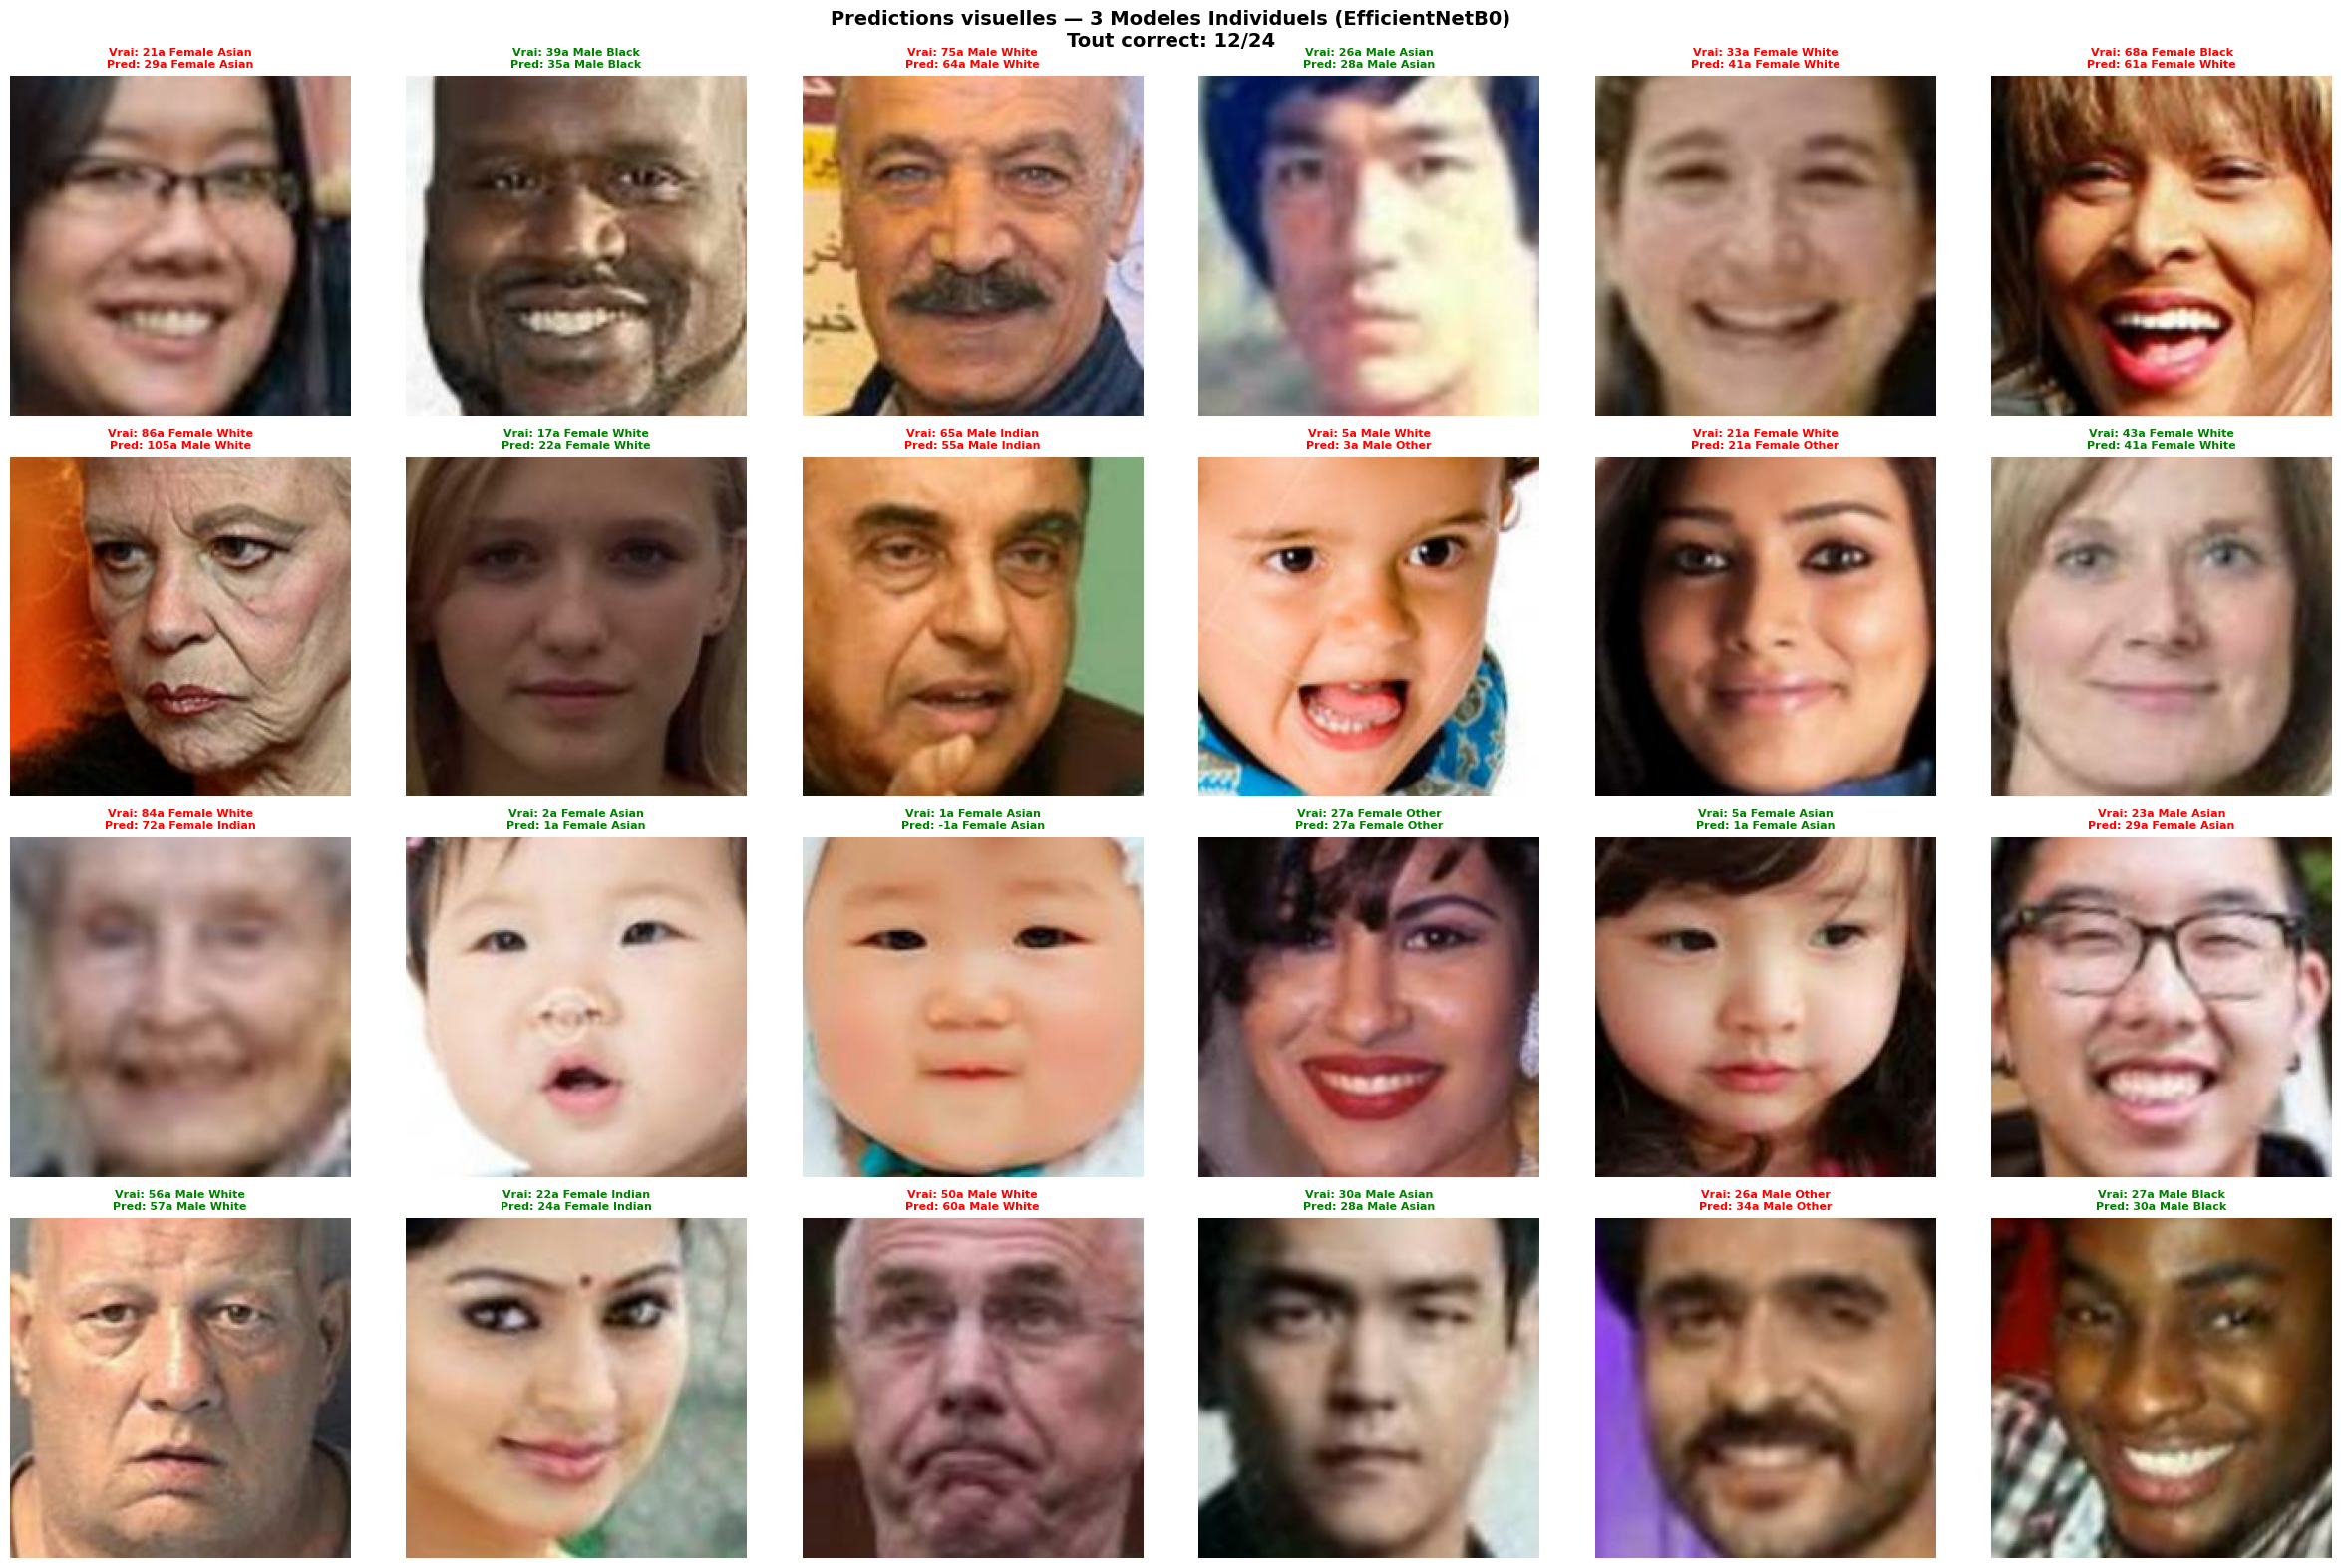

Tout correct (age±5 + genre + ethnicite): 12/24


0

In [ ]:
# Prediction visuelle - 3 modeles individuels sur le meme echantillon
import json as _json

custom_objects = {"SparseFocalLoss": SparseFocalLoss}
SAMPLE_SIZE = 24
np.random.seed(SEED)
sample_idx = np.random.choice(len(idx_test), SAMPLE_SIZE, replace=False)

# Charger les 3 modeles
keras.backend.clear_session()
gc.collect()
m_age = keras.models.load_model(
    os.path.join(OUTPUT_DIR, "age_best.keras"), custom_objects=custom_objects
)
m_gender = keras.models.load_model(
    os.path.join(OUTPUT_DIR, "gender_best.keras"), custom_objects=custom_objects
)
m_eth = keras.models.load_model(
    os.path.join(OUTPUT_DIR, "ethnicity_best.keras"), custom_objects=custom_objects
)

fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()
n_correct = 0

for i, si in enumerate(sample_idx):
    real_idx = idx_test[si]
    img_path = paths[real_idx]
    true_age = int(ages[real_idx])
    true_gender = GENDER_LABELS[int(genders[real_idx])]
    true_eth = ETHNICITY_LABELS[int(ethnicities[real_idx])]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img_resized = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_batch = tf.expand_dims(tf.cast(img_resized, tf.float32), 0)

    p_age = int(m_age.predict(img_batch, verbose=0)[0][0])
    p_gender_prob = m_gender.predict(img_batch, verbose=0)[0][0]
    p_gender = GENDER_LABELS[1 if p_gender_prob > 0.5 else 0]
    p_eth = ETHNICITY_LABELS[np.argmax(m_eth.predict(img_batch, verbose=0)[0])]

    gender_ok = p_gender == true_gender
    eth_ok = p_eth == true_eth
    age_ok = abs(p_age - true_age) <= 5
    all_ok = gender_ok and eth_ok and age_ok
    if all_ok:
        n_correct += 1

    axes[i].imshow(img.numpy().astype(np.uint8))
    axes[i].set_title(
        f"Vrai: {true_age}a {true_gender} {true_eth}\n"
        f"Pred: {p_age}a {p_gender} {p_eth}",
        fontsize=8,
        color="green" if all_ok else "red",
        fontweight="bold",
    )
    axes[i].axis("off")

plt.suptitle(
    f"Predictions visuelles — 3 Modeles Individuels ({best_backbone})\n"
    f"Tout correct: {n_correct}/{SAMPLE_SIZE}",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "individuels_predictions_visuelles.png"), dpi=150)
plt.show()
print(f"Tout correct (age±5 + genre + ethnicite): {n_correct}/{SAMPLE_SIZE}")

del m_age, m_gender, m_eth
keras.backend.clear_session()
gc.collect()

## 3.8 Resume et Export TFLite


In [ ]:
def export_tflite(keras_path, tflite_path, name):
    keras.backend.clear_session()
    gc.collect()
    custom_objects = {"SparseFocalLoss": SparseFocalLoss}
    model = keras.models.load_model(keras_path, custom_objects=custom_objects)
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    converter._experimental_lower_tensor_list_ops = False
    tflite_model = converter.convert()
    with open(tflite_path, "wb") as f:
        f.write(tflite_model)
    size_mb = len(tflite_model) / (1024 * 1024)
    print(f"  {name}: {size_mb:.1f} MB -> {tflite_path}")
    del model
    keras.backend.clear_session()
    gc.collect()


for task in ["age", "gender", "ethnicity"]:
    keras_p = os.path.join(OUTPUT_DIR, f"{task}_best.keras")
    tflite_p = os.path.join(OUTPUT_DIR, f"{task}_model.tflite")
    if os.path.exists(keras_p):
        export_tflite(keras_p, tflite_p, task.capitalize())

print("\nTous les modeles individuels entraines et exportes !")
print(f"Artefacts: {OUTPUT_DIR}")

INFO:tensorflow:Assets written to: /tmp/tmpi58kogpf/assets


INFO:tensorflow:Assets written to: /tmp/tmpi58kogpf/assets


Saved artifact at '/tmp/tmpi58kogpf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138300766978896: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138300766994064: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138304856067152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138304856067536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138304856069648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138304856068112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138304856066960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138304856066576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138304856067728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138304856067344: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1774634232.318022  155972 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774634232.318179  155972 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-27 18:57:12.321108: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpi58kogpf
2026-03-27 18:57:12.332902: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-27 18:57:12.332916: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpi58kogpf
I0000 00:00:1774634232.427162  155972 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-27 18:57:12.445415: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-27 18:57:13.070808: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpi58kogpf
2026-03-27 18:57:13.235402: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

  Age: 8.3 MB -> /home/optimalako/Projet/SAE/training/output_v2/age_model.tflite
INFO:tensorflow:Assets written to: /tmp/tmprkiqklmx/assets


...

  Gender: 8.3 MB -> /home/optimalako/Projet/SAE/training/output_v2/gender_model.tflite
INFO:tensorflow:Assets written to: /tmp/tmpzuu76nhz/assets


INFO:tensorflow:Assets written to: /tmp/tmpzuu76nhz/assets


Saved artifact at '/tmp/tmpzuu76nhz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138305235238736: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138305235223376: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138305234610576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305234611920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305234600784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305234610960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305234614992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305234610384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305234612688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138305234615376: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1774634256.562194  155972 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774634256.562214  155972 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-27 18:57:36.562354: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpzuu76nhz
2026-03-27 18:57:36.574463: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-27 18:57:36.574475: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpzuu76nhz
2026-03-27 18:57:36.685742: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-27 18:57:37.286458: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpzuu76nhz
2026-03-27 18:57:37.447606: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 885255 microseconds.


  Ethnicity: 8.3 MB -> /home/optimalako/Projet/SAE/training/output_v2/ethnicity_model.tflite

Tous les modeles individuels entraines et exportes !
Artefacts: /home/optimalako/Projet/SAE/training/output_v2


## Resume

**Strategie 1** : 3 modeles specialises entraines et exportes en TFLite.

Les 3 strategies du sujet sont maintenant implementees :

1. 3 modeles specialises (ce notebook)
2. Modele multitache MoE (`2_modele_multitache.ipynb`)
3. Comparaison des backbones (`1_comparaison_backbones.ipynb`)
